In [ ]:
pip install -q transformers datasets tokenizers torch scikit-learn pandas numpy matplotlib seaborn tqdm shap lime captum flask flask-cors pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.1 MB/s eta 0:00:00


In [ ]:
import os, sys, json, re, time, copy, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from tqdm.auto import tqdm
from IPython.display import display, HTML

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from datasets import load_dataset
from transformers import AutoModel, AutoTokenizer, get_linear_schedule_with_warmup
from sklearn.metrics import (
    classification_report, confusion_matrix, multilabel_confusion_matrix,
    f1_score, precision_score, recall_score, accuracy_score,
    hamming_loss, roc_auc_score, roc_curve,
)
from sklearn.preprocessing import MultiLabelBinarizer

warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️ Device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

🖥️ Device: cuda
   GPU: Tesla T4


In [ ]:
class Config:
    DATASET_NAME = "lex_glue"
    DATASET_CONFIG = "ecthr_a"
    MAX_SEQ_LENGTH = 512

    ARTICLE_LABELS = [
        "Art. 2 - Right to life", "Art. 3 - Prohibition of torture",
        "Art. 5 - Right to liberty/security", "Art. 6 - Right to a fair trial",
        "Art. 8 - Private/family life", "Art. 9 - Freedom of thought",
        "Art. 10 - Freedom of expression", "Art. 11 - Freedom of assembly",
        "Art. 14 - Prohibition of discrimination", "Art. P1-1 - Protection of property",
    ]
    ARTICLE_SHORT = [l.split(" - ")[0] for l in ARTICLE_LABELS]
    NUM_LABELS = 10

    MODEL_NAMES = {
        "bert": "bert-base-uncased",
        "roberta": "roberta-base",
        "legal-bert": "nlpaueb/legal-bert-base-uncased",
    }

    DATA_DIR = "/content/jurisight_data"
    MODEL_DIR = "/content/jurisight_models"
    OUTPUT_DIR = "/content/jurisight_outputs"

    BATCH_SIZE = 16
    NUM_EPOCHS = 5
    LEARNING_RATE = 2e-5
    WARMUP_RATIO = 0.1
    WEIGHT_DECAY = 0.01
    MAX_GRAD_NORM = 1.0
    PATIENCE = 3
    SEED = 42

    # Quality tuning
    DEFAULT_THRESHOLD = 0.5
    THRESHOLD_GRID = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

config = Config()
torch.manual_seed(config.SEED)
np.random.seed(config.SEED)
for d in [config.DATA_DIR, config.MODEL_DIR, config.OUTPUT_DIR]:
    os.makedirs(d, exist_ok=True)
print("✅ Config ready")


✅ Config ready


In [ ]:
class ECHRClassifier(nn.Module):
    """Multi-label classifier: Transformer encoder → classifier head."""
    def __init__(self, model_name, num_labels, dropout_rate=0.3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        h = self.encoder.config.hidden_size
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate), nn.Linear(h, 256), nn.ReLU(),
            nn.Dropout(dropout_rate), nn.Linear(256, num_labels),
        )
        self.model_name = model_name
        self.num_labels = num_labels

    def forward(self, input_ids, attention_mask, labels=None):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)
        logits = self.classifier(out.last_hidden_state[:, 0, :])
        result = {"logits": logits, "attentions": out.attentions}
        if labels is not None:
            result["loss"] = nn.BCEWithLogitsLoss()(logits, labels)
        return result

class ECHRDataset(Dataset):
    def __init__(self, input_ids, attention_mask, labels):
        self.input_ids = input_ids
        self.attention_mask = attention_mask
        self.labels = labels
    def __len__(self): return len(self.input_ids)
    def __getitem__(self, idx):
        return {"input_ids": self.input_ids[idx],
                "attention_mask": self.attention_mask[idx],
                "labels": self.labels[idx]}

def predict_text(text, model, tokenizer, device, max_length=512):
    """Helper: predict ECHR violations for a text string."""
    inputs = tokenizer(text, return_tensors="pt", max_length=max_length,
                       truncation=True, padding="max_length")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        outputs = model(inputs["input_ids"], inputs["attention_mask"])
    logits = outputs["logits"].cpu().numpy()[0]
    probs = 1 / (1 + np.exp(-logits))
    return probs, (probs > 0.5).astype(int), outputs

print("✅ Classes defined")

✅ Classes defined


In [ ]:
print("📥 Loading ECHR dataset...")
dataset = load_dataset(config.DATASET_NAME, config.DATASET_CONFIG)
for split, data in dataset.items():
    print(f"  {split}: {len(data)} samples")

📥 Loading ECHR dataset...


README.md: 0.00B [00:00, ?B/s]

ecthr_a/train-00000-of-00001.parquet:   0%|          | 0.00/42.4M [00:00<?, ?B/s]

ecthr_a/test-00000-of-00001.parquet:   0%|          | 0.00/5.68M [00:00<?, ?B/s]

ecthr_a/validation-00000-of-00001.parque(…):   0%|          | 0.00/5.26M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

  train: 9000 samples
  test: 1000 samples
  validation: 1000 samples


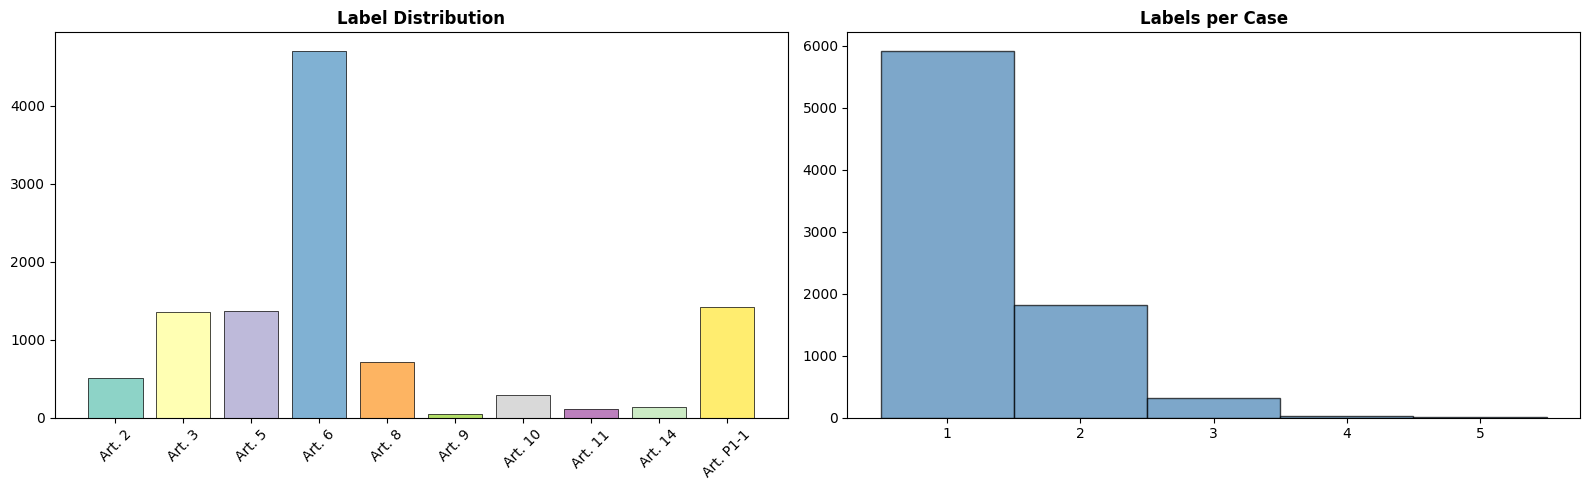

In [ ]:
train_data = dataset["train"]
all_labels = []
for item in train_data:
    all_labels.extend(item["labels"])
label_counts = Counter(all_labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
counts = [label_counts.get(i, 0) for i in range(config.NUM_LABELS)]
axes[0].bar(config.ARTICLE_SHORT, counts, color=plt.cm.Set3(np.linspace(0,1,10)), edgecolor="black", linewidth=0.5)
axes[0].set_title("Label Distribution", fontweight="bold"); axes[0].tick_params(axis="x", rotation=45)
labels_per = [len(item["labels"]) for item in train_data]
axes[1].hist(labels_per, bins=range(1, max(labels_per)+2), color="steelblue", edgecolor="black", alpha=0.7, align="left")
axes[1].set_title("Labels per Case", fontweight="bold")
plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/dataset_exploration.png", dpi=150); plt.show()

In [ ]:
def clean_legal_text(paragraphs):
    text = " ".join(paragraphs)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'^\d+\.\s*', '', text)
    text = re.sub(r'\s\d+\.\s', ' ', text)
    return text

def preprocess_split(split):
    texts = [clean_legal_text(item["text"]) for item in tqdm(split, desc="Cleaning")]
    mlb = MultiLabelBinarizer(classes=list(range(config.NUM_LABELS)))
    labels = mlb.fit_transform([item["labels"] for item in split]).tolist()
    return texts, labels

print("🧹 Preprocessing...")
train_texts, train_labels = preprocess_split(dataset["train"])
val_texts, val_labels = preprocess_split(dataset["validation"])
test_texts, test_labels = preprocess_split(dataset["test"])
print(f"✅ Train: {len(train_texts)}, Val: {len(val_texts)}, Test: {len(test_texts)}")

# Save raw text for XAI later
with open(f"{config.DATA_DIR}/test_processed.json", "w") as f:
    json.dump({"text": test_texts, "labels": test_labels}, f)

🧹 Preprocessing...


Cleaning:   0%|          | 0/9000 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/1000 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/1000 [00:00<?, ?it/s]

✅ Train: 9000, Val: 1000, Test: 1000


In [ ]:
print("🔤 Tokenizing for all models...")
tokenizers = {}
tokenized_data = {}

for model_key, model_name in config.MODEL_NAMES.items():
    print(f"  Tokenizing for {model_key}...")
    tok = AutoTokenizer.from_pretrained(model_name)
    tokenizers[model_key] = tok
    tokenized_data[model_key] = {}
    for split_name, texts, labels in [("train", train_texts, train_labels),
                                       ("val", val_texts, val_labels),
                                       ("test", test_texts, test_labels)]:
        enc = tok(texts, max_length=config.MAX_SEQ_LENGTH, truncation=True,
                  padding="max_length", return_tensors="pt")
        tokenized_data[model_key][split_name] = ECHRDataset(
            enc["input_ids"], enc["attention_mask"],
            torch.tensor(labels, dtype=torch.float32))

print("✅ Part 1 complete — data ready")

🔤 Tokenizing for all models...
  Tokenizing for bert...


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

✅ Part 1 complete — data ready


In [ ]:
def train_one_epoch(model, loader, optimizer, scheduler, device):
    model.train(); total_loss = 0; all_p = []; all_l = []
    for batch in tqdm(loader, desc="Train", leave=False):
        ids = batch["input_ids"].to(device)
        mask = batch["attention_mask"].to(device)
        labs = batch["labels"].to(device)
        optimizer.zero_grad()
        out = model(ids, mask, labs)
        out["loss"].backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.MAX_GRAD_NORM)
        optimizer.step(); scheduler.step()
        total_loss += out["loss"].item()
        preds = (torch.sigmoid(out["logits"]).cpu().detach().numpy() > 0.5).astype(int)
        all_p.extend(preds); all_l.extend(labs.cpu().numpy().astype(int))
    all_p, all_l = np.array(all_p), np.array(all_l)
    return total_loss/len(loader), f1_score(all_l, all_p, average="micro", zero_division=0), f1_score(all_l, all_p, average="macro", zero_division=0)

def evaluate_model(model, loader, device):
    model.eval(); total_loss = 0; all_p = []; all_l = []; all_prob = []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Eval", leave=False):
            ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            labs = batch["labels"].to(device)
            out = model(ids, mask, labs)
            total_loss += out["loss"].item()
            probs = torch.sigmoid(out["logits"]).cpu().numpy()
            all_prob.extend(probs)
            all_p.extend((probs > 0.5).astype(int))
            all_l.extend(labs.cpu().numpy().astype(int))
    all_p, all_l, all_prob = np.array(all_p), np.array(all_l), np.array(all_prob)
    return {"loss": total_loss/len(loader),
            "micro_f1": f1_score(all_l, all_p, average="micro", zero_division=0),
            "macro_f1": f1_score(all_l, all_p, average="macro", zero_division=0),
            "preds": all_p, "labels": all_l, "probs": all_prob}


In [ ]:
trained_models = {}
training_histories = {}
best_scores = {}

for model_key, model_name in config.MODEL_NAMES.items():
    print(f"\n{'='*60}\n🚀 Training: {model_key.upper()} ({model_name})\n{'='*60}")
    model = ECHRClassifier(model_name, config.NUM_LABELS).to(device)
    train_loader = DataLoader(tokenized_data[model_key]["train"], batch_size=config.BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(tokenized_data[model_key]["val"], batch_size=config.BATCH_SIZE*2, shuffle=False, num_workers=2, pin_memory=True)
    total_steps = len(train_loader) * config.NUM_EPOCHS
    optimizer = AdamW(model.parameters(), lr=config.LEARNING_RATE, weight_decay=config.WEIGHT_DECAY)
    scheduler = get_linear_schedule_with_warmup(optimizer, int(total_steps * config.WARMUP_RATIO), total_steps)

    best_f1 = 0; best_state = None; patience = 0
    history = {"train_loss":[], "val_loss":[], "train_f1":[], "val_f1":[], "train_macro_f1":[], "val_macro_f1":[]}

    for epoch in range(config.NUM_EPOCHS):
        t_loss, t_mic, t_mac = train_one_epoch(model, train_loader, optimizer, scheduler, device)
        v = evaluate_model(model, val_loader, device)
        for k, val in [("train_loss",t_loss),("val_loss",v["loss"]),("train_f1",t_mic),("val_f1",v["micro_f1"]),("train_macro_f1",t_mac),("val_macro_f1",v["macro_f1"])]:
            history[k].append(val)
        print(f"  Ep {epoch+1}: Train F1={t_mic:.4f} | Val F1={v['micro_f1']:.4f}")
        if v["micro_f1"] > best_f1:
            best_f1 = v["micro_f1"]; best_state = copy.deepcopy(model.state_dict()); patience = 0
            print(f"  ⭐ New best!")
        else:
            patience += 1
            if patience >= config.PATIENCE:
                print(f"  🛑 Early stopping"); break

    model.load_state_dict(best_state)
    save_dir = f"{config.MODEL_DIR}/{model_key}"
    os.makedirs(save_dir, exist_ok=True)
    torch.save({"model_state_dict": best_state, "model_name": model_name,
                "num_labels": config.NUM_LABELS, "best_val_f1": best_f1, "history": history},
               f"{save_dir}/best_model.pt")
    tokenizers[model_key].save_pretrained(save_dir)
    trained_models[model_key] = model
    training_histories[model_key] = history
    best_scores[model_key] = best_f1
    torch.cuda.empty_cache() if torch.cuda.is_available() else None

print("\n📊 Training Summary:")
for k, s in best_scores.items(): print(f"  {k.upper()}: {s:.4f}")


🚀 Training: BERT (bert-base-uncased)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Train:   0%|          | 0/563 [00:00<?, ?it/s]

...

  Ep 4: Train F1=0.8237 | Val F1=0.6963
  ⭐ New best!


Train:   0%|          | 0/563 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7caa926f76a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7caa926f76a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Eval:   0%|          | 0/32 [00:00<?, ?it/s]

  Ep 5: Train F1=0.8490 | Val F1=0.6950

📊 Training Summary:
  BERT: 0.6725
  ROBERTA: 0.6989
  LEGAL-BERT: 0.6963


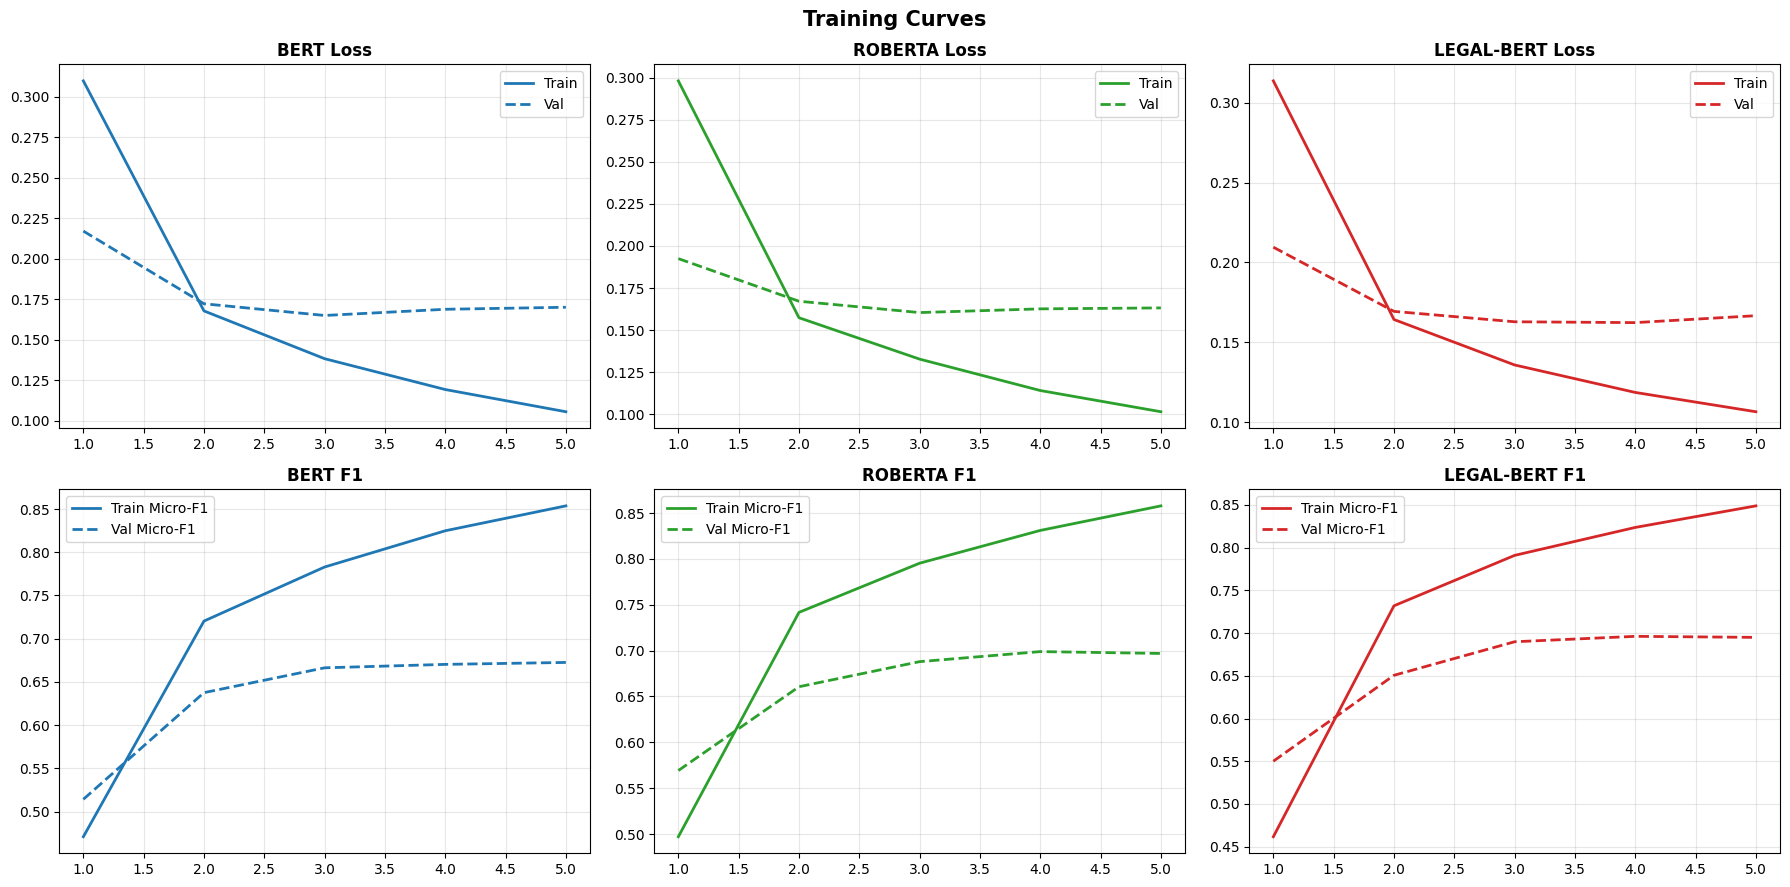

✅ Part 2 complete — models trained


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 9))
colors = {"bert": "#1f77b4", "roberta": "#2ca02c", "legal-bert": "#d62728"}
for i, mk in enumerate(config.MODEL_NAMES):
    h = training_histories[mk]; epochs = range(1, len(h["train_loss"])+1); c = colors[mk]
    axes[0][i].plot(epochs, h["train_loss"], c=c, lw=2, label="Train")
    axes[0][i].plot(epochs, h["val_loss"], c=c, lw=2, ls="--", label="Val")
    axes[0][i].set_title(f"{mk.upper()} Loss", fontweight="bold"); axes[0][i].legend(); axes[0][i].grid(alpha=0.3)
    axes[1][i].plot(epochs, h["train_f1"], c=c, lw=2, label="Train Micro-F1")
    axes[1][i].plot(epochs, h["val_f1"], c=c, lw=2, ls="--", label="Val Micro-F1")
    axes[1][i].set_title(f"{mk.upper()} F1", fontweight="bold"); axes[1][i].legend(); axes[1][i].grid(alpha=0.3)
plt.suptitle("Training Curves", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/training_curves.png", dpi=150); plt.show()
print("✅ Part 2 complete — models trained")

In [ ]:
# === CELL: Mount Google Drive ===
from google.colab import drive
drive.mount('/content/drive')

DRIVE_SAVE_DIR = "/content/drive/MyDrive/Jurisight_Models"
import os
os.makedirs(DRIVE_SAVE_DIR, exist_ok=True)
print(f"✅ Google Drive mounted. Models will be saved to: {DRIVE_SAVE_DIR}")


Mounted at /content/drive
✅ Google Drive mounted. Models will be saved to: /content/drive/MyDrive/Jurisight_Models


In [ ]:
# === CELL: Save Trained Models to Google Drive ===
import shutil

for model_key in config.MODEL_NAMES:
    src = f"{config.MODEL_DIR}/{model_key}"
    dst = f"{DRIVE_SAVE_DIR}/{model_key}"
    if os.path.exists(src):
        shutil.copytree(src, dst, dirs_exist_ok=True)
        print(f"✅ Saved {model_key} to Google Drive")

# Also save comparison CSV and fairness results later
print("🎉 All models saved to Google Drive! You can skip training next time.")


✅ Saved bert to Google Drive
✅ Saved roberta to Google Drive
✅ Saved legal-bert to Google Drive
🎉 All models saved to Google Drive! You can skip training next time.


In [ ]:
from sklearn.metrics import f1_score

def optimize_thresholds(y_true, y_probs, grid):
    """Per-label threshold tuning on validation set for macro-F1 balance."""
    best = []
    for i in range(y_true.shape[1]):
        y_i = y_true[:, i]
        p_i = y_probs[:, i]
        best_t, best_f1 = 0.5, -1
        for t in grid:
            pred_i = (p_i > t).astype(int)
            score = f1_score(y_i, pred_i, zero_division=0)
            if score > best_f1:
                best_f1 = score
                best_t = float(t)
        best.append(best_t)
    return best

print("🎯 Tuning thresholds on validation set...")
model_thresholds = {}
for mk in config.MODEL_NAMES:
    val_loader = DataLoader(tokenized_data[mk]["val"], batch_size=config.BATCH_SIZE*2, shuffle=False)
    val_res = evaluate_model(trained_models[mk], val_loader, device)
    model_thresholds[mk] = optimize_thresholds(val_res["labels"], val_res["probs"], config.THRESHOLD_GRID)
    print(f"  {mk.upper()} thresholds: {[round(t,2) for t in model_thresholds[mk]]}")

with open(f"{config.OUTPUT_DIR}/model_thresholds.json", "w") as f:
    json.dump(model_thresholds, f, indent=2)

print("📊 Evaluating on test set with tuned thresholds...")
test_results = {}
for mk in config.MODEL_NAMES:
    loader = DataLoader(tokenized_data[mk]["test"], batch_size=config.BATCH_SIZE*2, shuffle=False)
    r = evaluate_model(trained_models[mk], loader, device)
    th = np.array(model_thresholds[mk])[None, :]
    tuned_preds = (r["probs"] > th).astype(int)
    test_results[mk] = {"labels": r["labels"], "preds": tuned_preds, "probs": r["probs"], "thresholds": model_thresholds[mk]}
    micro = f1_score(r["labels"], tuned_preds, average="micro", zero_division=0)
    macro = f1_score(r["labels"], tuned_preds, average="macro", zero_division=0)
    print(f"  {mk.upper()}: Micro-F1={micro:.4f}, Macro-F1={macro:.4f}")


📊 Evaluating on test set...


Eval:   0%|          | 0/32 [00:00<?, ?it/s]

  BERT: Micro-F1=0.6631, Macro-F1=0.5112


Eval:   0%|          | 0/32 [00:00<?, ?it/s]

  ROBERTA: Micro-F1=0.6808, Macro-F1=0.5350


Eval:   0%|          | 0/32 [00:00<?, ?it/s]

  LEGAL-BERT: Micro-F1=0.6779, Macro-F1=0.5303


In [ ]:
rows = []
for mk in config.MODEL_NAMES:
    l, p, pr = test_results[mk]["labels"], test_results[mk]["preds"], test_results[mk]["probs"]
    row = {"Model": mk.upper(),
           "Micro-F1": f1_score(l, p, average="micro", zero_division=0),
           "Macro-F1": f1_score(l, p, average="macro", zero_division=0),
           "Precision": precision_score(l, p, average="micro", zero_division=0),
           "Recall": recall_score(l, p, average="micro", zero_division=0),
           "Hamming Loss": hamming_loss(l, p),
           "Subset Acc": accuracy_score(l, p)}
    try: row["ROC-AUC"] = roc_auc_score(l, pr, average="macro")
    except: row["ROC-AUC"] = np.nan
    rows.append(row)
comparison_df = pd.DataFrame(rows)
print("\n📋 Model Comparison:")
print(comparison_df.to_string(index=False, float_format="%.4f"))
comparison_df.to_csv(f"{config.OUTPUT_DIR}/model_comparison.csv", index=False)


📋 Model Comparison:
     Model  Micro-F1  Macro-F1  Precision  Recall  Hamming Loss  Subset Acc  ROC-AUC
      BERT    0.6631    0.5112     0.7099  0.6220        0.0689      0.5100   0.8946
   ROBERTA    0.6808    0.5350     0.7163  0.6486        0.0663      0.5150   0.9053
LEGAL-BERT    0.6779    0.5303     0.7371  0.6275        0.0650      0.5320   0.8806


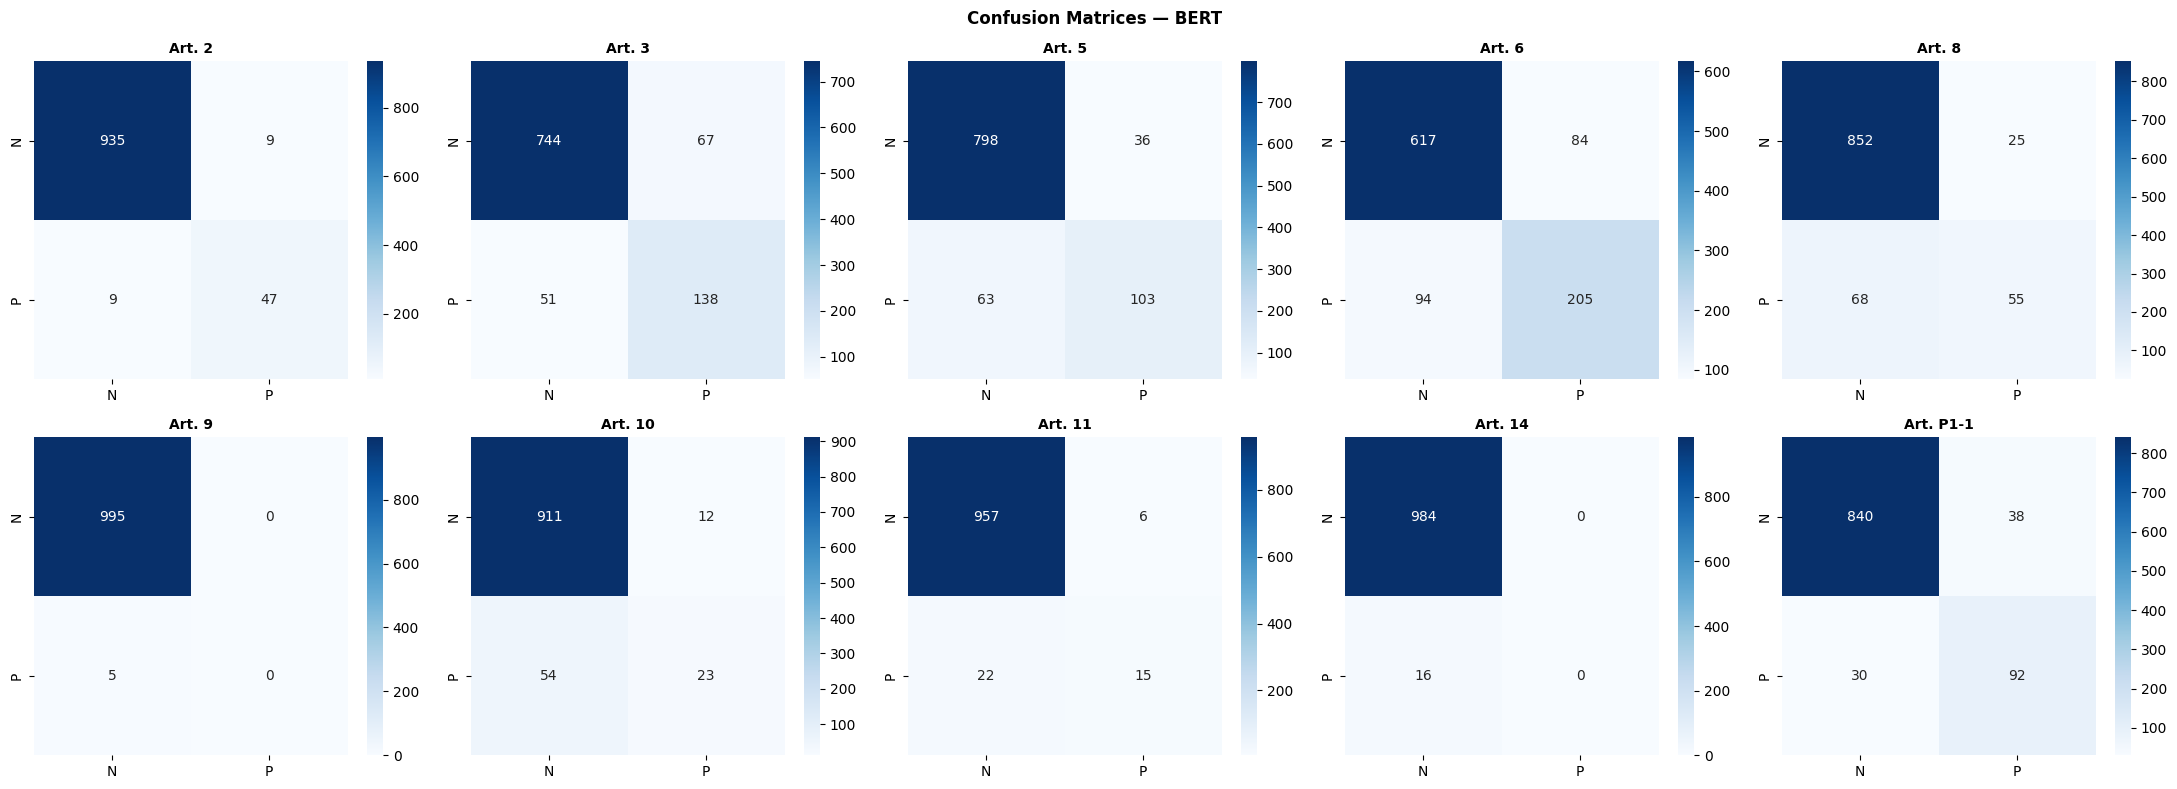

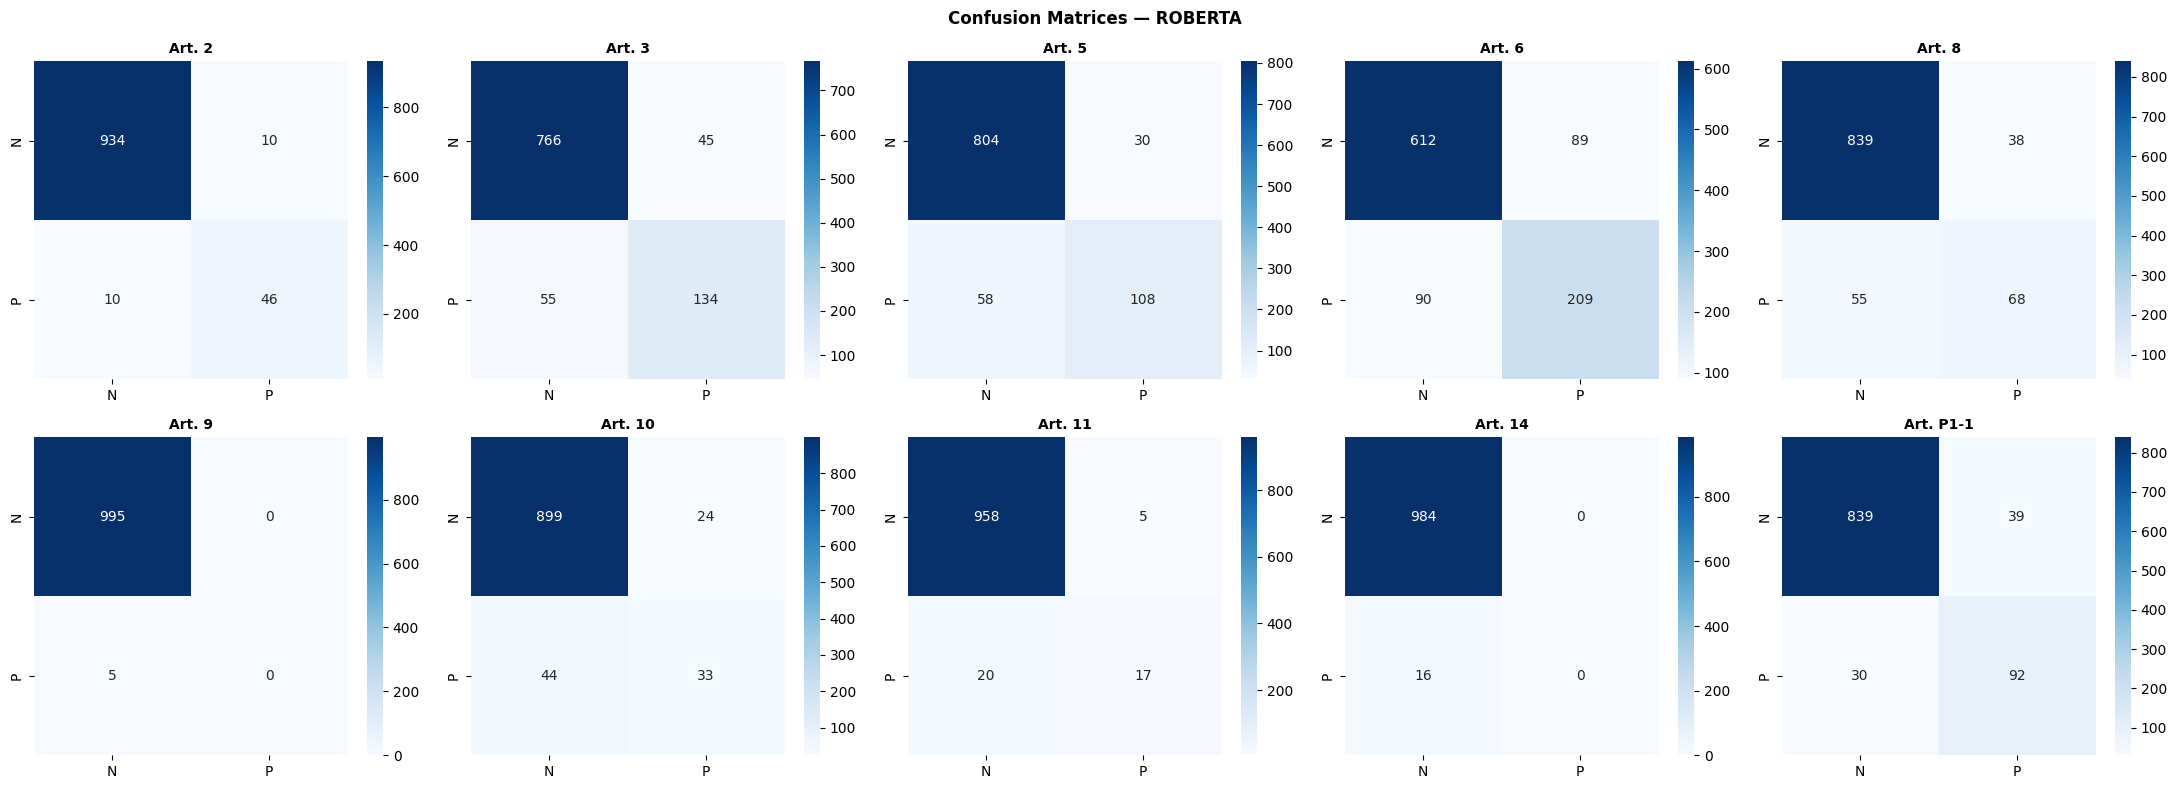

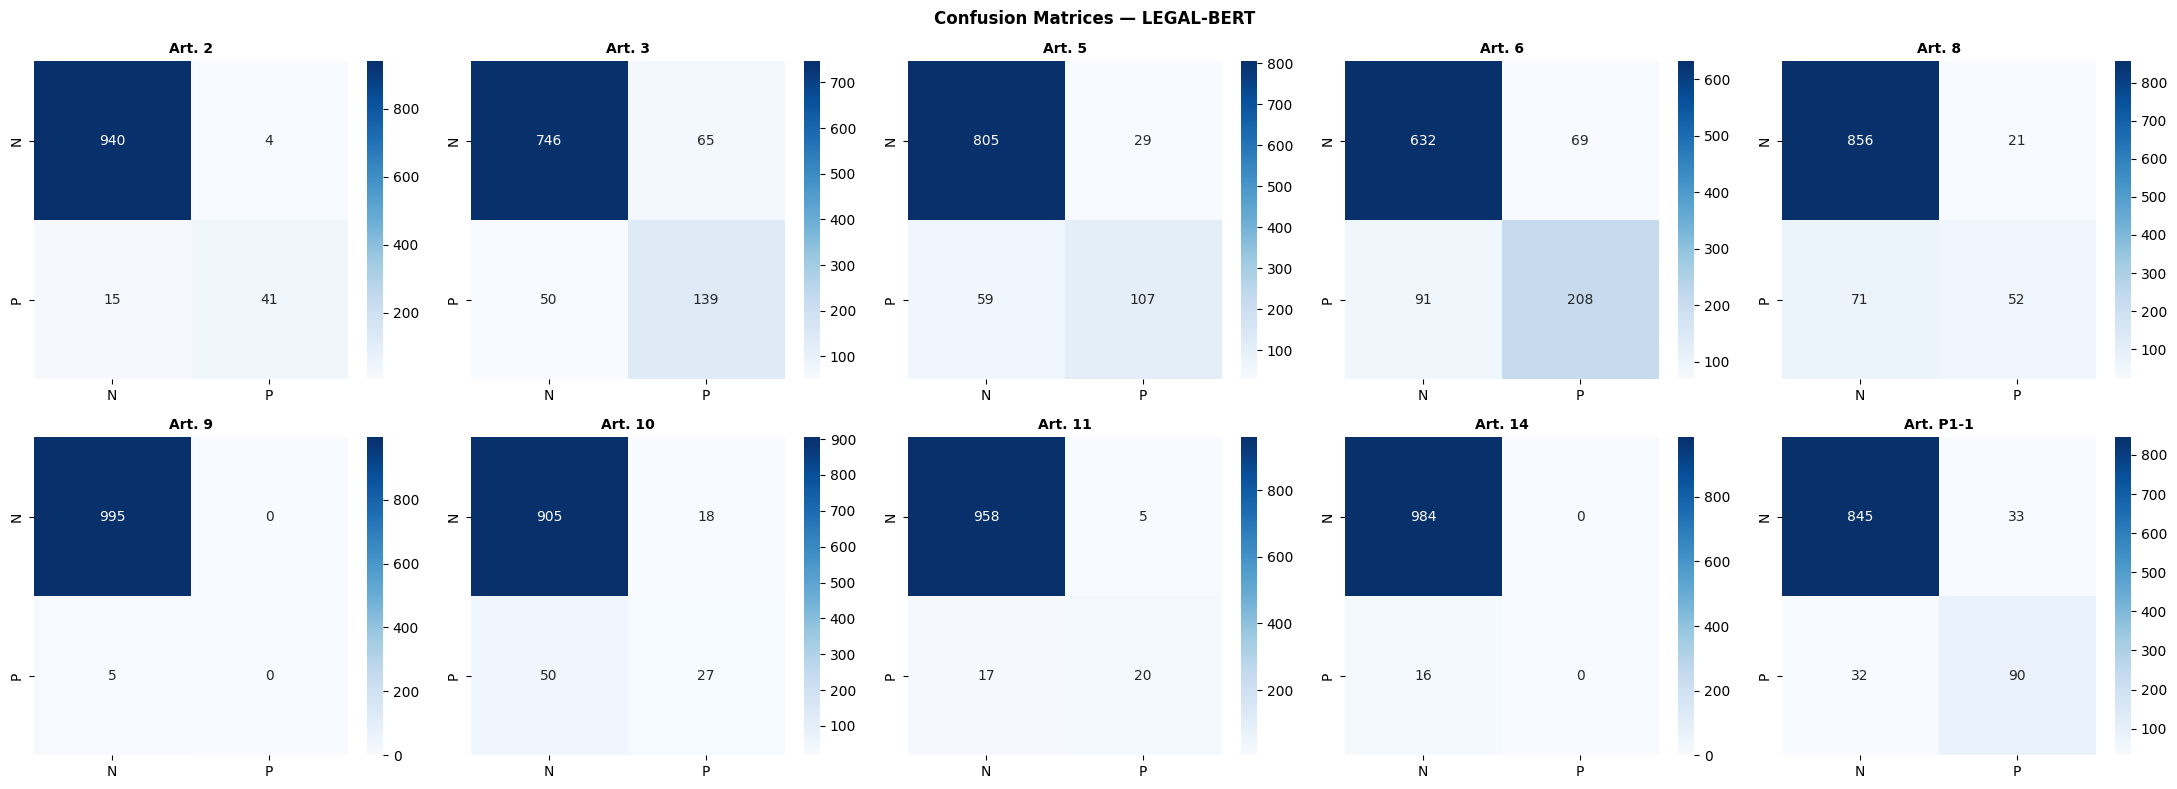

In [ ]:
for mk in config.MODEL_NAMES:
    l, p = test_results[mk]["labels"], test_results[mk]["preds"]
    mcm = multilabel_confusion_matrix(l, p)
    fig, axes = plt.subplots(2, 5, figsize=(22, 8))
    for i, (cm, ax) in enumerate(zip(mcm, axes.flatten())):
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=["N","P"], yticklabels=["N","P"])
        ax.set_title(config.ARTICLE_SHORT[i], fontsize=10, fontweight="bold")
    plt.suptitle(f"Confusion Matrices — {mk.upper()}", fontweight="bold")
    plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/cm_{mk}.png", dpi=150); plt.show()

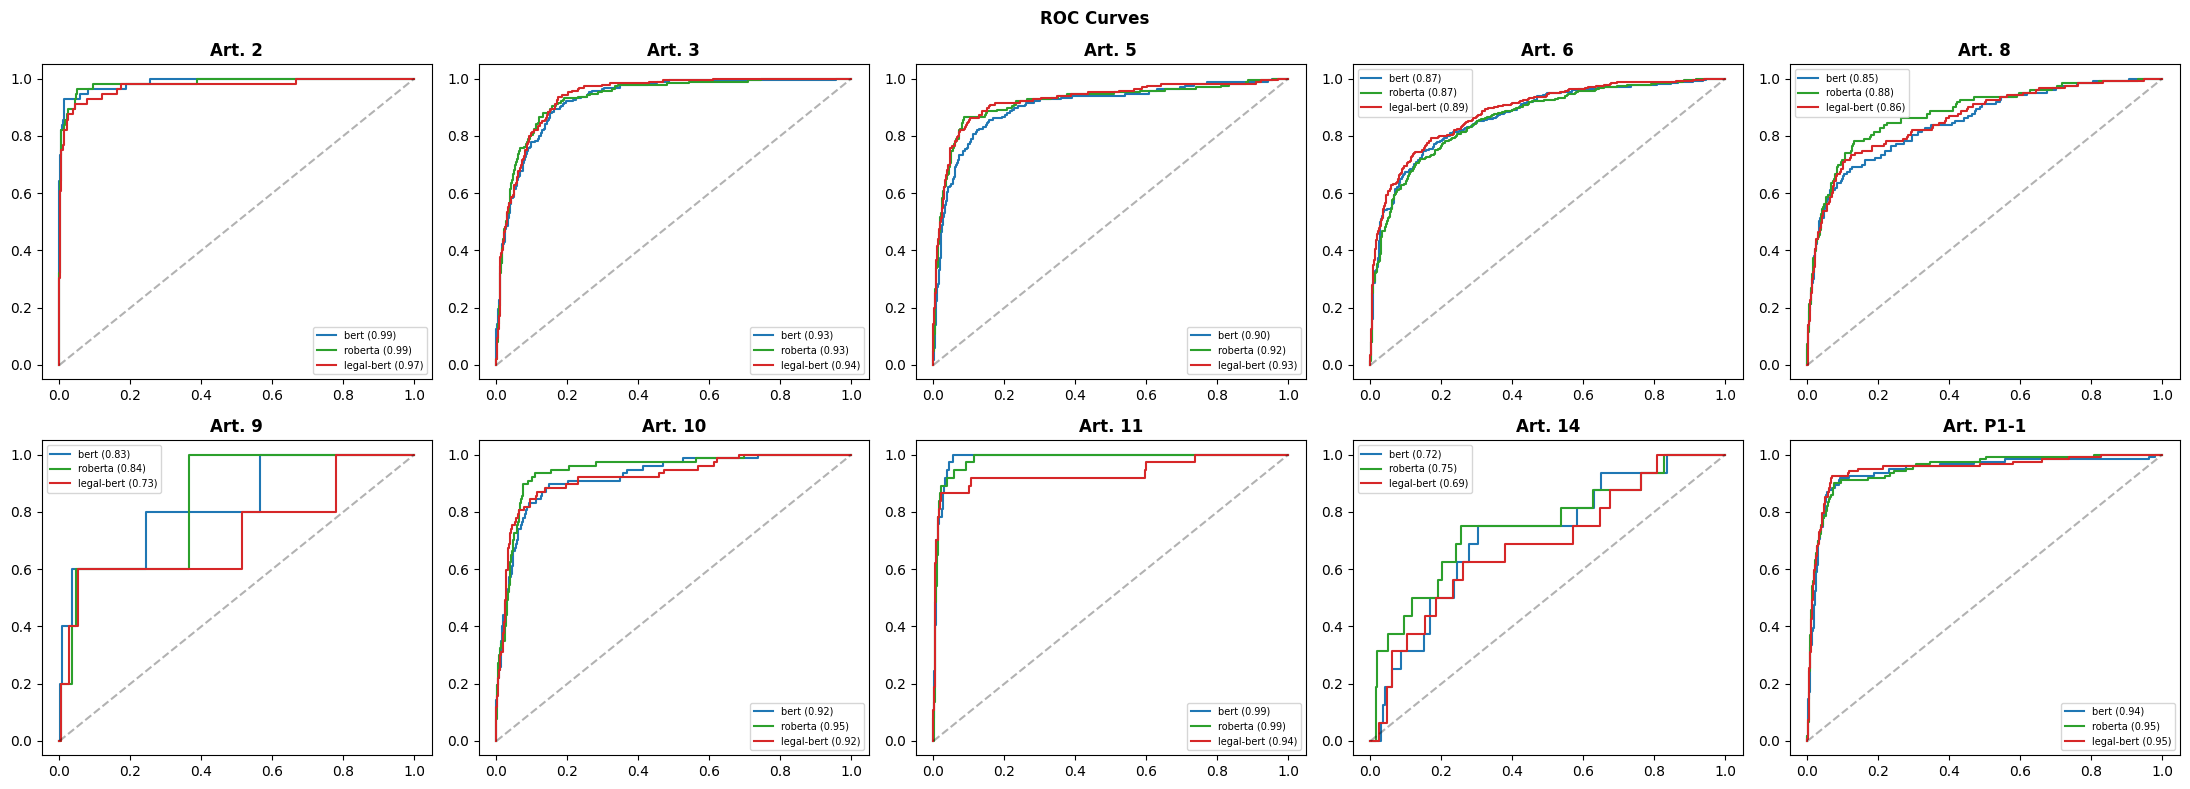

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))
clr = {"bert":"#1f77b4","roberta":"#2ca02c","legal-bert":"#d62728"}
for i, ax in enumerate(axes.flatten()):
    for mk in config.MODEL_NAMES:
        lc = test_results[mk]["labels"][:, i]; pc = test_results[mk]["probs"][:, i]
        if len(np.unique(lc)) < 2: continue
        fpr, tpr, _ = roc_curve(lc, pc)
        auc = roc_auc_score(lc, pc)
        ax.plot(fpr, tpr, color=clr[mk], label=f"{mk} ({auc:.2f})", lw=1.5)
    ax.plot([0,1],[0,1],'k--',alpha=0.3); ax.set_title(config.ARTICLE_SHORT[i], fontweight="bold")
    ax.legend(fontsize=7)
plt.suptitle("ROC Curves", fontweight="bold")
plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/roc_curves.png", dpi=150); plt.show()



⚖️ Fairness Analysis:
  BERT: F1 StdDev=0.2805, Range=0.8393
  ROBERTA: F1 StdDev=0.2818, Range=0.8214
  LEGAL-BERT: F1 StdDev=0.2836, Range=0.8119


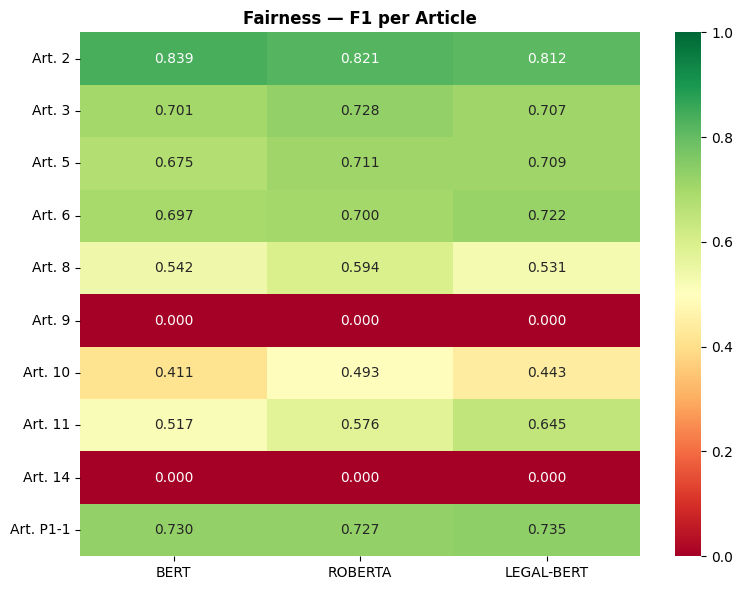

✅ Part 3 complete — evaluation done


In [ ]:
print("\n⚖️ Fairness Analysis:")
fairness_results = {}
for mk in config.MODEL_NAMES:
    l, p = test_results[mk]["labels"], test_results[mk]["preds"]
    f1s = [f1_score(l[:,i], p[:,i], zero_division=0) for i in range(config.NUM_LABELS)]
    print(f"  {mk.upper()}: F1 StdDev={np.std(f1s):.4f}, Range={max(f1s)-min(f1s):.4f}")
    fairness_results[mk] = {config.ARTICLE_SHORT[i]: {"F1": f1s[i], "Support": int(l[:,i].sum())} for i in range(config.NUM_LABELS)}

# Heatmap
data = {mk.upper(): [fairness_results[mk][a]["F1"] for a in config.ARTICLE_SHORT] for mk in config.MODEL_NAMES}
df_fair = pd.DataFrame(data, index=config.ARTICLE_SHORT)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(df_fair, annot=True, fmt=".3f", cmap="RdYlGn", vmin=0, vmax=1, ax=ax)
ax.set_title("Fairness — F1 per Article", fontweight="bold")
plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/fairness_heatmap.png", dpi=150); plt.show()

with open(f"{config.OUTPUT_DIR}/fairness_results.json", "w") as f:
    json.dump({mk: {k: {kk: float(vv) for kk,vv in v.items()} for k,v in cls.items()} for mk, cls in fairness_results.items()}, f, indent=2)

print("✅ Part 3 complete — evaluation done")

In [ ]:
import shap
import lime
import lime.lime_text
from captum.attr import IntegratedGradients

os.makedirs(f"{config.OUTPUT_DIR}/xai", exist_ok=True)

# Use the best model for XAI (change if needed)
xai_model_key = "legal-bert"
xai_model = trained_models[xai_model_key]
xai_tokenizer = tokenizers[xai_model_key]

# Load test text samples
with open(f"{config.DATA_DIR}/test_processed.json") as f:
    test_raw = json.load(f)

print(f"🔍 Using {xai_model_key} for XAI. Test samples: {len(test_raw['text'])}")

🔍 Using legal-bert for XAI. Test samples: 1000



📊 SHAP-style Feature Importance (Perturbation-based)


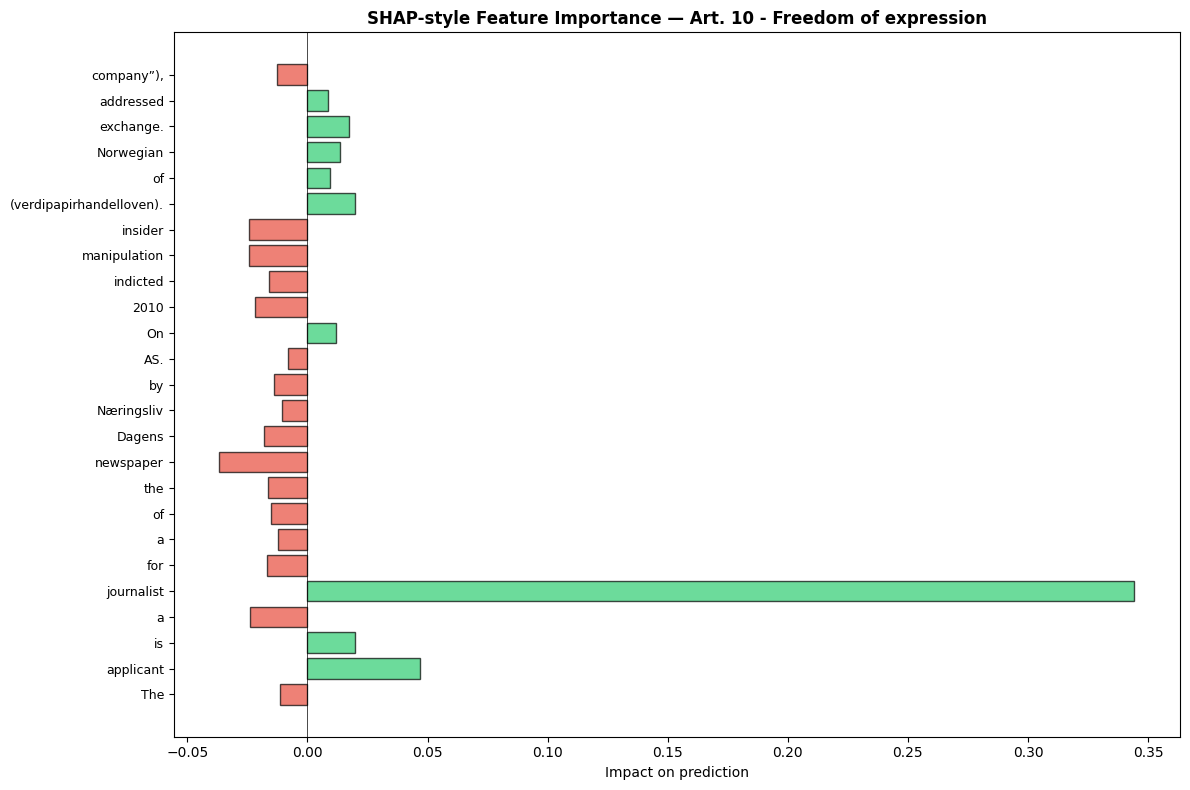

✅ SHAP-style analysis done


In [ ]:
print("\n📊 SHAP-style Feature Importance (Perturbation-based)")
sample_text = test_raw["text"][0]

def shap_perturbation(text, model, tokenizer, device, config, n_words=100):
    """Remove each word and measure prediction drop."""
    words = text.split()[:n_words]
    base_probs, _, _ = predict_text(" ".join(words), model, tokenizer, device)
    target = np.argmax(base_probs)
    importances = []
    for i in range(len(words)):
        masked = words[:i] + words[i+1:]
        m_probs, _, _ = predict_text(" ".join(masked), model, tokenizer, device)
        importances.append(base_probs[target] - m_probs[target])
    return words, np.array(importances), target

words, imp, target_art = shap_perturbation(sample_text, xai_model, xai_tokenizer, device, config)

top_k = min(25, len(words))
top_idx = np.argsort(np.abs(imp))[-top_k:]
fig, ax = plt.subplots(figsize=(12, 8))
tw = [words[j] for j in sorted(top_idx)]
ti = [imp[j] for j in sorted(top_idx)]
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in ti]
ax.barh(range(len(tw)), ti, color=colors, edgecolor="black", alpha=0.7)
ax.set_yticks(range(len(tw))); ax.set_yticklabels(tw, fontsize=9)
ax.set_title(f"SHAP-style Feature Importance — {config.ARTICLE_LABELS[target_art]}", fontweight="bold")
ax.set_xlabel("Impact on prediction"); ax.axvline(0, color="black", lw=0.5)
plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/xai/shap_features.png", dpi=150); plt.show()
print("✅ SHAP-style analysis done")


🍋 LIME Explainability


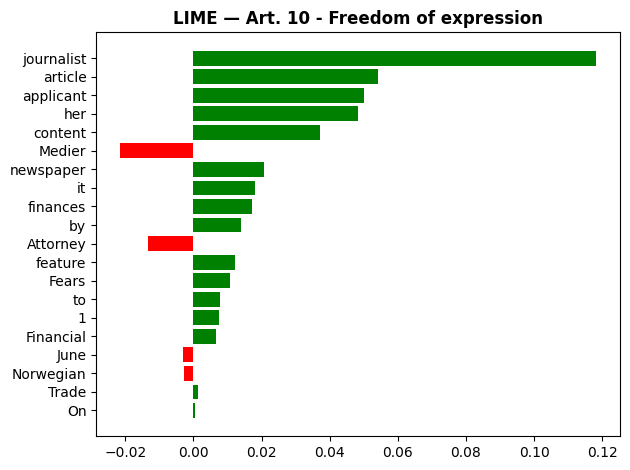

  Top LIME features:
    ↑ 'journalist': 0.1182
    ↑ 'article': 0.0541
    ↑ 'applicant': 0.0500
    ↑ 'her': 0.0482
    ↑ 'content': 0.0371
    ↓ 'Medier': -0.0216
    ↑ 'newspaper': 0.0206
    ↑ 'it': 0.0180
    ↑ 'finances': 0.0172
    ↑ 'by': 0.0140
✅ LIME done


In [ ]:
print("\n🍋 LIME Explainability")

def lime_predict_fn(texts):
    """LIME needs a function: texts → probabilities."""
    all_probs = []
    for t in texts:
        p, _, _ = predict_text(t, xai_model, xai_tokenizer, device)
        all_probs.append(p)
    return np.array(all_probs)

explainer = lime.lime_text.LimeTextExplainer(
    class_names=config.ARTICLE_LABELS, split_expression=r'\W+', bow=True)

short_text = " ".join(sample_text.split()[:300])
probs, preds, _ = predict_text(short_text, xai_model, xai_tokenizer, device)
target_label = np.argmax(probs)

lime_exp = explainer.explain_instance(
    short_text, lime_predict_fn, num_features=20, num_samples=200, labels=[target_label])

fig = lime_exp.as_pyplot_figure(label=target_label)
plt.title(f"LIME — {config.ARTICLE_LABELS[target_label]}", fontweight="bold")
plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/xai/lime_explanation.png", dpi=150, bbox_inches="tight"); plt.show()

print("  Top LIME features:")
for word, weight in lime_exp.as_list(label=target_label)[:10]:
    d = "↑" if weight > 0 else "↓"
    print(f"    {d} '{word}': {weight:.4f}")
print("✅ LIME done")

In [ ]:
print("\n🧬 Captum — Integrated Gradients")

def captum_explain(text, model, tokenizer, device, target_label=None):
    inputs = tokenizer(text, return_tensors="pt", max_length=512, truncation=True, padding="max_length")
    input_ids = inputs["input_ids"].to(device)
    attn_mask = inputs["attention_mask"].to(device)
    probs, preds, _ = predict_text(text, model, tokenizer, device)
    if target_label is None:
        target_label = np.argmax(probs)
    def fwd(ids, mask):
        return model(ids, mask)["logits"]
    ref_ids = torch.zeros_like(input_ids)
    ref_ids[:] = tokenizer.pad_token_id if tokenizer.pad_token_id is not None else 0
    ig = IntegratedGradients(fwd)
    attrs, _ = ig.attribute(input_ids, ref_ids, additional_forward_args=(attn_mask,),
                            target=target_label, return_convergence_delta=True, n_steps=50)
    attrs = attrs.sum(dim=-1).squeeze(0).cpu().detach().numpy()
    actual_len = int(attn_mask.sum().item())
    tokens = tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).cpu().numpy())[:actual_len]
    attrs = attrs[:actual_len]
    attrs = attrs / (np.max(np.abs(attrs)) + 1e-10)
    return tokens, attrs, target_label, probs

try:
    sample_short = " ".join(sample_text.split()[:150])
    cpt_tokens, cpt_attrs, cpt_target, cpt_probs = captum_explain(
        sample_short, xai_model, xai_tokenizer, device)

    top_k = min(25, len(cpt_tokens))
    abs_a = np.abs(cpt_attrs)
    top_idx = sorted(np.argsort(abs_a)[-top_k:])
    fig, ax = plt.subplots(figsize=(12, 8))
    tt = [cpt_tokens[j] for j in top_idx]
    ta = [cpt_attrs[j] for j in top_idx]
    colors = ["#2ecc71" if a > 0 else "#e74c3c" for a in ta]
    ax.barh(range(len(tt)), ta, color=colors, edgecolor="black", alpha=0.8)
    ax.set_yticks(range(len(tt))); ax.set_yticklabels(tt, fontsize=9)
    ax.set_title(f"Integrated Gradients — {config.ARTICLE_LABELS[cpt_target]}", fontweight="bold")
    ax.set_xlabel("Attribution"); ax.axvline(0, color="black", lw=0.8); ax.invert_yaxis()
    plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/xai/captum_ig.png", dpi=150); plt.show()
    print("✅ Captum Integrated Gradients done")
except Exception as e:
    print(f"⚠️ Captum error: {e}")


🧬 Captum — Integrated Gradients
⚠️ Captum error: Expected tensor for argument #1 'indices' to have one of the following scalar types: Long, Int; but got torch.cuda.FloatTensor instead (while checking arguments for embedding)


In [ ]:
print("\n👁️ Attention Visualization")

inputs = xai_tokenizer(sample_text, return_tensors="pt", max_length=512, truncation=True, padding="max_length")
input_ids = inputs["input_ids"].to(device)
attn_mask = inputs["attention_mask"].to(device)
with torch.no_grad():
    out = xai_model(input_ids, attn_mask)
attn = out["attentions"][-1][0]  # last layer, (heads, seq, seq)
actual_len = int(attn_mask.sum().item())
tokens = xai_tokenizer.convert_ids_to_tokens(input_ids.squeeze(0).cpu().numpy())[:actual_len]
avg_cls_attn = attn[:, 0, :actual_len].mean(dim=0).cpu().numpy()

# Filter special tokens
filtered = [(t, a) for t, a in zip(tokens, avg_cls_attn) if t not in ["[CLS]","[SEP]","[PAD]","<s>","</s>","<pad>"]]
if filtered:
    ft, fa = zip(*filtered)
    top_k = min(30, len(ft))
    top_idx = np.argsort(fa)[-top_k:]
    fig, ax = plt.subplots(figsize=(12, 8))
    tt = [ft[j] for j in sorted(top_idx)]
    ta = [fa[j] for j in sorted(top_idx)]
    colors_a = plt.cm.YlOrRd(np.array(ta) / max(ta))
    ax.barh(range(len(tt)), ta, color=colors_a, edgecolor="black", alpha=0.8)
    ax.set_yticks(range(len(tt))); ax.set_yticklabels(tt, fontsize=9)
    ax.set_title("CLS Attention (Average Heads, Last Layer)", fontweight="bold")
    ax.set_xlabel("Attention Weight"); ax.invert_yaxis()
    plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/xai/attention_cls.png", dpi=150); plt.show()

    # Text heatmap
    max_a = max(fa)
    html = '<div style="font-family:monospace;line-height:2.2;padding:10px;">'
    html += '<h3>Attention Heatmap</h3>'
    for t, a in list(zip(ft, fa))[:100]:
        intensity = min(a / max_a * 2, 1.0)
        html += f'<span style="background:rgba(102,126,234,{intensity:.2f});padding:2px 4px;margin:1px;border-radius:3px;">{t}</span> '
    html += '</div>'
    display(HTML(html))
    with open(f"{config.OUTPUT_DIR}/xai/attention_heatmap.html", "w") as f:
        f.write(html)
print("✅ Attention visualization done")


👁️ Attention Visualization


TypeError: 'NoneType' object is not subscriptable


🔲 Occlusion-based Sentence Importance
  Target: Art. 10 - Freedom of expression (conf: 0.6145)
  Top 5 important sentences:
    1. [+0.2898] The applicant is a journalist for DN.no, a Norwegian Internet-based version of the newspaper Dagens ...
    2. [+0.1094] The Oslo stock exchange (Oslo børs) suspected market manipulation and, having looked into the matter...
    3. [+0.0394] Other media also reported on the first article, including an online newspaper (Hegnar online) which ...
    4. [+0.0196] The following day, on Saturday 25 August 2007, the applicant wrote an article entitled “Fears of DNO...
    5. [+0.0000] Information identifying a source In order to protect the identity of a source adequately, it is nece...


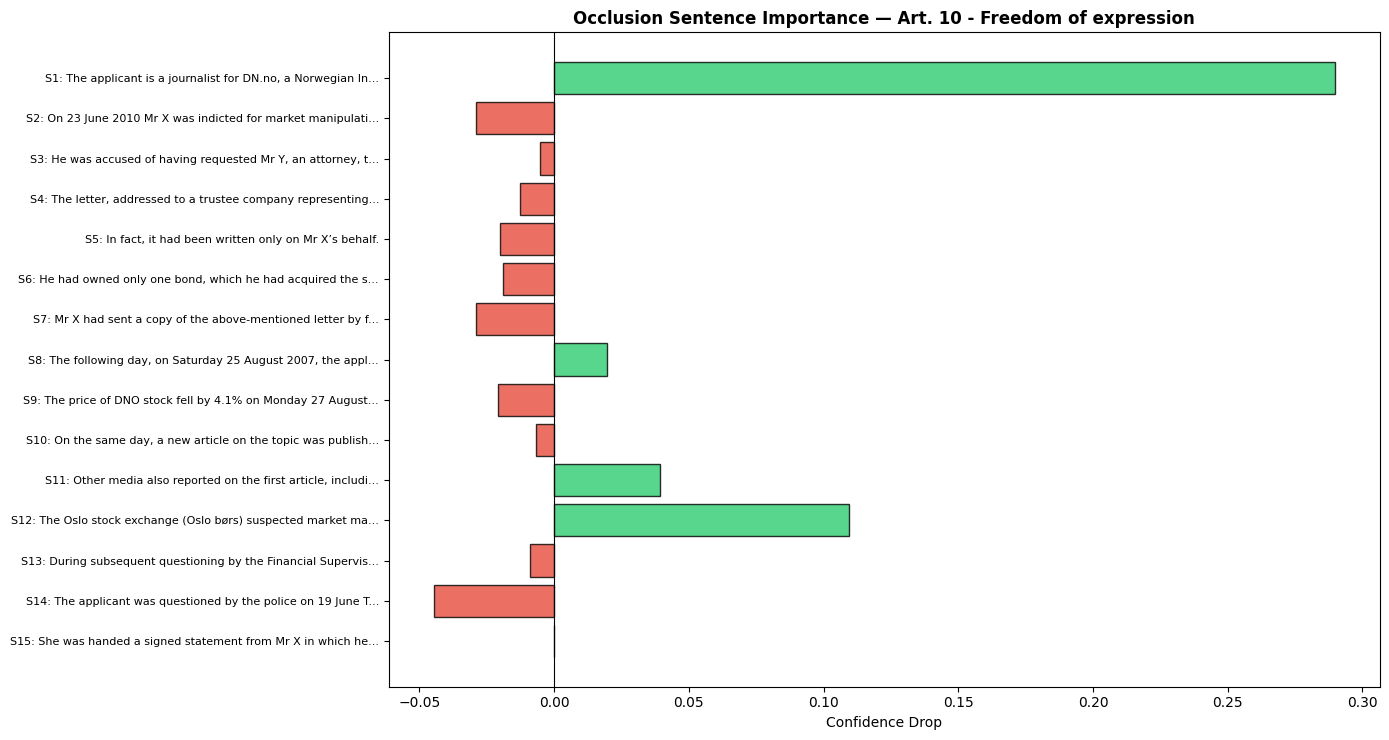

In [ ]:
print("\n🔲 Occlusion-based Sentence Importance")

sentences = re.split(r'(?<=[.!?])\s+', sample_text)
sentences = [s.strip() for s in sentences if len(s.strip()) > 10]
base_probs, _, _ = predict_text(sample_text, xai_model, xai_tokenizer, device)
occ_target = np.argmax(base_probs)
base_conf = base_probs[occ_target]

occ_scores = []
for i, s in enumerate(sentences):
    occ_text = " ".join([ss for j, ss in enumerate(sentences) if j != i])
    occ_probs, _, _ = predict_text(occ_text, xai_model, xai_tokenizer, device)
    occ_scores.append(base_conf - occ_probs[occ_target])

sorted_idx = np.argsort(occ_scores)[::-1]
print(f"  Target: {config.ARTICLE_LABELS[occ_target]} (conf: {base_conf:.4f})")
print(f"  Top 5 important sentences:")
for rank, idx in enumerate(sorted_idx[:5]):
    print(f"    {rank+1}. [{occ_scores[idx]:+.4f}] {sentences[idx][:100]}...")

fig, ax = plt.subplots(figsize=(14, max(6, len(sentences[:15]) * 0.5)))
display_s = [f"S{i+1}: {s[:55]}..." if len(s)>55 else f"S{i+1}: {s}" for i, s in enumerate(sentences[:15])]
display_sc = occ_scores[:15]
colors_o = ["#2ecc71" if s > 0 else "#e74c3c" for s in display_sc]
ax.barh(range(len(display_s)), display_sc, color=colors_o, edgecolor="black", alpha=0.8)
ax.set_yticks(range(len(display_s))); ax.set_yticklabels(display_s, fontsize=8)
ax.set_title(f"Occlusion Sentence Importance — {config.ARTICLE_LABELS[occ_target]}", fontweight="bold")
ax.set_xlabel("Confidence Drop"); ax.axvline(0, color="black", lw=0.8); ax.invert_yaxis()
plt.tight_layout(); plt.savefig(f"{config.OUTPUT_DIR}/xai/occlusion_sentences.png", dpi=150); plt.show()


In [ ]:
xai_summary = pd.DataFrame({
    "Method": ["SHAP-style", "LIME", "Integrated Gradients", "Attention", "Occlusion"],
    "Type": ["Model-agnostic", "Model-agnostic", "Gradient-based", "Internal", "Perturbation"],
    "Granularity": ["Word", "Word", "Token", "Token", "Sentence"],
})
print("\n📋 XAI Methods Summary:")
print(xai_summary.to_string(index=False))
print("\n✅ Part 4 complete — XAI done")


📋 XAI Methods Summary:
              Method           Type Granularity
          SHAP-style Model-agnostic        Word
                LIME Model-agnostic        Word
Integrated Gradients Gradient-based       Token
           Attention       Internal       Token
           Occlusion   Perturbation    Sentence

✅ Part 4 complete — XAI done


In [ ]:
APP_DIR = "/content/jurisight_webapp"
os.makedirs(f"{APP_DIR}/static/css", exist_ok=True)
os.makedirs(f"{APP_DIR}/static/js", exist_ok=True)
os.makedirs(f"{APP_DIR}/templates", exist_ok=True)

# --- app.py (Flask backend) ---
flask_code = """
import os, json, re, torch, numpy as np
import torch.nn as nn
from flask import Flask, request, jsonify, render_template
from flask_cors import CORS
from transformers import AutoModel, AutoTokenizer

app = Flask(__name__)
CORS(app, resources={r"/api/*": {"origins": os.getenv("CORS_ORIGINS", "*")}})
MODEL_DIR = "/content/jurisight_models"
OUTPUT_DIR = "/content/jurisight_outputs"
THRESHOLD_FILE = f"{OUTPUT_DIR}/model_thresholds.json"
LABELS = ["Art. 2 - Right to life","Art. 3 - Prohibition of torture","Art. 5 - Right to liberty/security","Art. 6 - Right to a fair trial","Art. 8 - Private/family life","Art. 9 - Freedom of thought","Art. 10 - Freedom of expression","Art. 11 - Freedom of assembly","Art. 14 - Prohibition of discrimination","Art. P1-1 - Protection of property"]
MODELS = {"bert":"bert-base-uncased","roberta":"roberta-base","legal-bert":"nlpaueb/legal-bert-base-uncased"}

class ECHRClassifier(nn.Module):
    def __init__(s, model_name, num_labels, dr=0.3):
        super().__init__()
        s.encoder = AutoModel.from_pretrained(model_name)
        h = s.encoder.config.hidden_size
        s.classifier = nn.Sequential(nn.Dropout(dr),nn.Linear(h,256),nn.ReLU(),nn.Dropout(dr),nn.Linear(256,num_labels))
    def forward(s, input_ids, attention_mask):
        out = s.encoder(input_ids=input_ids, attention_mask=attention_mask, output_attentions=True)
        return {"logits": s.classifier(out.last_hidden_state[:,0,:]), "attentions": out.attentions}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
cache = {}

if os.path.exists(THRESHOLD_FILE):
    with open(THRESHOLD_FILE) as f:
        MODEL_THRESHOLDS = json.load(f)
else:
    MODEL_THRESHOLDS = {k: [0.5] * len(LABELS) for k in MODELS}

def get_model(key):
    if key not in MODELS:
        raise ValueError(f"Unknown model key: {key}")
    if key in cache: return cache[key]
    cp = torch.load(f"{MODEL_DIR}/{key}/best_model.pt", map_location=device, weights_only=False)
    m = ECHRClassifier(cp["model_name"], cp["num_labels"]); m.load_state_dict(cp["model_state_dict"]); m.to(device); m.eval()
    t = AutoTokenizer.from_pretrained(cp["model_name"]); cache[key] = (m, t); return m, t

@app.route("/")
def index(): return render_template("index.html")

@app.route("/api/health")
def health(): return jsonify({"status": "ok"})

@app.route("/api/predict", methods=["POST"])
def predict():
    d = request.json or {}
    text = d.get("text",""); mk = d.get("model","legal-bert"); user_th = d.get("threshold", None)
    if not text: return jsonify({"error":"No text"}), 400
    try:
        m, t = get_model(mk)
    except Exception as e:
        return jsonify({"error": str(e)}), 400
    inp = t(text, return_tensors="pt", max_length=512, truncation=True, padding="max_length")
    inp = {k:v.to(device) for k,v in inp.items()}
    with torch.no_grad(): out = m(inp["input_ids"], inp["attention_mask"])
    probs = (1/(1+np.exp(-out["logits"].cpu().numpy()[0]))).tolist()
    thresholds = [float(user_th)] * len(LABELS) if user_th is not None else MODEL_THRESHOLDS.get(mk, [0.5] * len(LABELS))
    return jsonify({"predictions":[{"label":l,"probability":round(p,4),"threshold":round(float(th),4),"predicted":p>float(th)} for l,p,th in zip(LABELS,probs,thresholds)],"model":mk})

@app.route("/api/explain/attention", methods=["POST"])
def attn():
    d = request.json; m, t = get_model(d.get("model","legal-bert"))
    inp = t(d["text"], return_tensors="pt", max_length=512, truncation=True, padding="max_length")
    inp = {k:v.to(device) for k,v in inp.items()}
    with torch.no_grad(): out = m(inp["input_ids"], inp["attention_mask"])
    a = out["attentions"][-1][0]; al = int(inp["attention_mask"].sum().item())
    toks = t.convert_ids_to_tokens(inp["input_ids"].squeeze(0).cpu().numpy())[:al]
    avg = a[:,0,:al].mean(dim=0).cpu().numpy().tolist()
    return jsonify({"tokens":[{"token":tk,"attention":round(at,6)} for tk,at in zip(toks,avg) if tk not in ["[CLS]","[SEP]","[PAD]","<s>","</s>","<pad>"]]})

@app.route("/api/explain/occlusion", methods=["POST"])
def occ():
    d = request.json; m, t = get_model(d.get("model","legal-bert")); text = d["text"]
    sents = [s.strip() for s in re.split(r"(?<=[.!?])\\s+", text) if len(s.strip())>10]
    def gp(tx):
        i = t(tx, return_tensors="pt", max_length=512, truncation=True, padding="max_length")
        i = {k:v.to(device) for k,v in i.items()}
        with torch.no_grad(): o = m(i["input_ids"], i["attention_mask"])
        return (1/(1+np.exp(-o["logits"].cpu().numpy()[0]))).tolist()
    bp = gp(text); tgt = int(np.argmax(bp))
    res = [{"sentence":s,"importance":round(bp[tgt]-gp(" ".join([ss for j,ss in enumerate(sents) if j!=i]))[tgt],6)} for i,s in enumerate(sents)]
    return jsonify({"sentences":res,"target_article":LABELS[tgt],"base_confidence":round(bp[tgt],4)})

@app.route("/api/explain/feature_importance", methods=["POST"])
def feat():
    d = request.json; m, t = get_model(d.get("model","legal-bert")); words = d["text"].split()[:80]
    def gp(tx):
        i = t(tx, return_tensors="pt", max_length=512, truncation=True, padding="max_length")
        i = {k:v.to(device) for k,v in i.items()}
        with torch.no_grad(): o = m(i["input_ids"], i["attention_mask"])
        return (1/(1+np.exp(-o["logits"].cpu().numpy()[0]))).tolist()
    bp = gp(" ".join(words)); tgt = int(np.argmax(bp))
    res = sorted([{"word":w,"importance":round(bp[tgt]-gp(" ".join(words[:i]+words[i+1:]))[tgt],6)} for i,w in enumerate(words)], key=lambda x:abs(x["importance"]), reverse=True)[:30]
    return jsonify({"words":res,"target_article":LABELS[tgt],"base_confidence":round(bp[tgt],4)})

@app.route("/api/comparison")
def comp():
    import pandas as pd
    p = f"{OUTPUT_DIR}/model_comparison.csv"
    if os.path.exists(p): return jsonify(pd.read_csv(p).to_dict(orient="records"))
    return jsonify({"error":"No data"}), 404

@app.route("/api/models")
def models():
    return jsonify([{"key":k,"name":v,"available":os.path.exists(f"{MODEL_DIR}/{k}/best_model.pt"), "thresholds": MODEL_THRESHOLDS.get(k, [0.5]*len(LABELS))} for k,v in MODELS.items()])

if __name__ == "__main__": app.run(host="0.0.0.0", port=5000, debug=False)
"""
with open(f"{APP_DIR}/app.py", "w") as f: f.write(flask_code)
print("✅ Flask app.py created")


✅ Flask app.py created


In [ ]:
html_code = r'''<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8"><meta name="viewport" content="width=device-width,initial-scale=1.0">
<title>Jurisight — Legal AI</title>
<meta name="description" content="Interpretable Legal Document Classification and Verdict Prediction">
<link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700;800&display=swap" rel="stylesheet">
<link rel="stylesheet" href="{{ url_for('static', filename='css/style.css') }}">
</head>
<body>
<nav class="navbar"><div class="nav-brand"><span class="nav-icon">&#9878;</span><span class="nav-title">Jurisight</span></div>
<div class="nav-links"><a href="#" class="nav-link active" onclick="showPage('home')">Home</a><a href="#" class="nav-link" onclick="showPage('predict')">Predict</a><a href="#" class="nav-link" onclick="showPage('compare')">Compare</a><a href="#" class="nav-link" onclick="showPage('explain')">Explain</a></div></nav>

<section id="home" class="page active">
<div class="hero"><div class="hero-content">
<h1 class="hero-title"><span class="gradient-text">Jurisight</span></h1>
<p class="hero-subtitle">Interpretable Legal Document Classification<br>& Verdict Prediction System</p>
<p class="hero-desc">Powered by Transformer-based NLP and Explainable AI for the ECHR</p>
<button class="btn btn-primary btn-lg" onclick="showPage('predict')">Start Predicting &#8594;</button>
</div></div>
<div class="container"><div class="features-grid">
<div class="feature-card"><div class="feature-icon">&#129302;</div><h3>AI Models</h3><p>BERT, RoBERTa, Legal-BERT fine-tuned for ECHR case analysis.</p></div>
<div class="feature-card"><div class="feature-icon">&#128202;</div><h3>Verdict Prediction</h3><p>Predict violated articles of the European Convention on Human Rights.</p></div>
<div class="feature-card"><div class="feature-icon">&#128270;</div><h3>Explainable AI</h3><p>SHAP, LIME, Attention, Integrated Gradients, and Occlusion explanations.</p></div>
<div class="feature-card"><div class="feature-icon">&#9878;</div><h3>Fairness</h3><p>Evaluate model fairness across different ECHR articles.</p></div>
</div></div></section>

<section id="predict" class="page">
<div class="container"><h1 class="page-title">&#9878; Verdict Prediction</h1>
<div class="predict-layout"><div class="input-panel">
<div class="form-group"><label>Model</label><select id="model-select" class="form-select"><option value="bert">BERT</option><option value="roberta">RoBERTa</option><option value="legal-bert" selected>Legal-BERT</option></select></div>
<div class="form-group"><label>Threshold: <span id="threshold-val">0.50</span></label><input type="range" id="threshold-slider" min="0.1" max="0.9" step="0.05" value="0.5" class="form-range"></div>
<div class="form-group"><label>Case Facts</label><textarea id="case-text" class="form-textarea" rows="10" placeholder="Paste ECHR case facts..."></textarea></div>
<div class="btn-group"><button class="btn btn-primary" id="predict-btn" onclick="runPrediction()">&#128302; Predict</button><button class="btn btn-secondary" onclick="loadExample()">&#128203; Example</button></div>
</div><div class="results-panel" id="results-panel" style="display:none"><h2>Results</h2><div id="results-summary"></div><div id="results-cards"></div></div>
</div></div></section>

<section id="compare" class="page">
<div class="container"><h1 class="page-title">&#128202; Model Comparison</h1>
<div id="comparison-loading" class="loading">Loading...</div><div id="comparison-table" style="display:none"></div></div></section>

<section id="explain" class="page">
<div class="container"><h1 class="page-title">&#128270; Explainable AI</h1>
<div class="explain-layout"><div class="input-panel">
<div class="form-group"><label>Model</label><select id="xai-model" class="form-select"><option value="bert">BERT</option><option value="roberta">RoBERTa</option><option value="legal-bert" selected>Legal-BERT</option></select></div>
<div class="form-group"><label>XAI Method</label><select id="xai-method" class="form-select"><option value="attention">Attention Visualization</option><option value="occlusion">Occlusion Sentence Importance</option><option value="feature">Feature Importance (SHAP-style)</option></select></div>
<div class="form-group"><label>Case Facts</label><textarea id="xai-text" class="form-textarea" rows="8" placeholder="Enter case facts..."></textarea></div>
<button class="btn btn-primary" onclick="runExplanation()">&#128270; Explain</button>
</div><div class="xai-results" id="xai-results" style="display:none"><h2 id="xai-title"></h2><div id="xai-content"></div></div>
</div></div></section>

<footer class="footer"><p>&#9878; Jurisight — Built with Transformers, XAI, and &#10084;</p></footer>
<script src="{{ url_for('static', filename='js/app.js') }}"></script>
</body></html>'''
with open(f"{APP_DIR}/templates/index.html", "w") as f: f.write(html_code)
print("✅ HTML created")

✅ HTML created


In [ ]:
css_code = r'''*,*::before,*::after{box-sizing:border-box;margin:0;padding:0}
body{font-family:'Inter',sans-serif;background:#0a0a1a;color:#e0e0e0;min-height:100vh}
.navbar{position:fixed;top:0;left:0;right:0;z-index:100;display:flex;align-items:center;justify-content:space-between;padding:.8rem 2rem;background:rgba(10,10,26,.9);backdrop-filter:blur(20px);border-bottom:1px solid rgba(255,255,255,.06)}
.nav-brand{display:flex;align-items:center;gap:.6rem}.nav-icon{font-size:1.6rem}
.nav-title{font-size:1.3rem;font-weight:700;background:linear-gradient(135deg,#667eea,#764ba2);-webkit-background-clip:text;-webkit-text-fill-color:transparent}
.nav-links{display:flex;gap:.5rem}.nav-link{color:#888;text-decoration:none;padding:.5rem 1rem;border-radius:8px;font-weight:500;font-size:.9rem;transition:.3s}
.nav-link:hover,.nav-link.active{color:#fff;background:rgba(102,126,234,.15)}
.hero{min-height:90vh;display:flex;align-items:center;justify-content:center;text-align:center;padding:6rem 2rem 4rem;background:radial-gradient(ellipse at top,rgba(102,126,234,.15) 0%,transparent 60%)}
.hero-title{font-size:4.5rem;font-weight:800;margin-bottom:1rem;letter-spacing:-2px}
.gradient-text{background:linear-gradient(135deg,#667eea,#764ba2,#f093fb);-webkit-background-clip:text;-webkit-text-fill-color:transparent}
.hero-subtitle{font-size:1.4rem;color:#aaa;margin-bottom:.8rem;line-height:1.6}.hero-desc{font-size:1rem;color:#666;margin-bottom:2.5rem}
.container{max-width:1200px;margin:0 auto;padding:2rem}
.btn{display:inline-flex;align-items:center;gap:.5rem;padding:.7rem 1.6rem;border:none;border-radius:10px;font-family:inherit;font-size:.95rem;font-weight:600;cursor:pointer;transition:.3s}
.btn-primary{background:linear-gradient(135deg,#667eea,#764ba2);color:#fff;box-shadow:0 4px 15px rgba(102,126,234,.3)}
.btn-primary:hover{transform:translateY(-2px)}.btn-secondary{background:rgba(255,255,255,.08);color:#ccc;border:1px solid rgba(255,255,255,.1)}
.btn-lg{padding:1rem 2.2rem;font-size:1.05rem}.btn-group{display:flex;gap:1rem;margin-top:1rem}
.features-grid{display:grid;grid-template-columns:repeat(auto-fit,minmax(250px,1fr));gap:1.5rem;margin:3rem 0}
.feature-card{background:rgba(255,255,255,.04);border:1px solid rgba(255,255,255,.06);border-radius:16px;padding:2rem;transition:.3s}
.feature-card:hover{transform:translateY(-5px);border-color:rgba(102,126,234,.3)}
.feature-icon{font-size:2.5rem;margin-bottom:1rem}.feature-card h3{font-size:1.15rem;margin-bottom:.6rem;color:#fff}.feature-card p{font-size:.9rem;color:#888;line-height:1.6}
.page{display:none;padding-top:5rem;min-height:100vh;animation:fadeIn .4s}.page.active{display:block}
@keyframes fadeIn{from{opacity:0;transform:translateY(10px)}to{opacity:1;transform:none}}
.page-title{font-size:2.2rem;font-weight:700;margin-bottom:1.5rem}
.form-group{margin-bottom:1.2rem}.form-group label{display:block;font-weight:600;margin-bottom:.4rem;font-size:.9rem;color:#ccc}
.form-select,.form-textarea{width:100%;padding:.7rem 1rem;border-radius:10px;background:rgba(255,255,255,.06);border:1px solid rgba(255,255,255,.1);color:#e0e0e0;font-family:inherit;font-size:.95rem}
.form-select:focus,.form-textarea:focus{outline:none;border-color:#667eea}.form-textarea{resize:vertical;min-height:150px}.form-range{width:100%;accent-color:#667eea}
.predict-layout,.explain-layout{display:grid;grid-template-columns:1fr 1fr;gap:2rem}
.input-panel,.results-panel,.xai-results{background:rgba(255,255,255,.03);border:1px solid rgba(255,255,255,.06);border-radius:16px;padding:2rem}
.result-card{display:flex;align-items:center;justify-content:space-between;padding:.8rem 1rem;margin:.5rem 0;border-radius:10px;background:rgba(255,255,255,.04);border-left:4px solid}
.result-card.violation{border-color:#2ecc71}.result-card.no-violation{border-color:#555}
.result-label{font-weight:500;font-size:.9rem}.result-bar-bg{width:120px;height:6px;background:rgba(255,255,255,.1);border-radius:3px;overflow:hidden;margin:0 1rem}
.result-bar{height:100%;border-radius:3px;transition:width .8s}.result-prob{font-weight:600;font-size:.9rem;min-width:50px;text-align:right}
.bar-chart{margin:1rem 0}.bar-item{display:flex;align-items:center;margin:.3rem 0;font-size:.85rem}
.bar-label{min-width:120px;text-align:right;padding-right:.8rem;overflow:hidden;text-overflow:ellipsis;white-space:nowrap}
.bar-fill-container{flex:1;height:20px;background:rgba(255,255,255,.05);border-radius:4px;overflow:hidden;position:relative}
.bar-fill{height:100%;border-radius:4px;transition:width .6s;position:absolute}
.bar-positive{background:linear-gradient(90deg,rgba(46,204,113,.6),#2ecc71);left:50%}.bar-negative{background:linear-gradient(270deg,rgba(231,76,60,.6),#e74c3c);right:50%}
.bar-value{min-width:60px;text-align:left;padding-left:.8rem;font-weight:500}
.data-table{width:100%;border-collapse:collapse;margin:1rem 0;background:rgba(255,255,255,.03);border-radius:12px;overflow:hidden}
.data-table th{background:rgba(102,126,234,.15);color:#fff;padding:.8rem;font-size:.85rem;text-align:left;font-weight:600}
.data-table td{padding:.7rem .8rem;border-bottom:1px solid rgba(255,255,255,.04);font-size:.85rem}
.data-table tr:hover td{background:rgba(255,255,255,.03)}.highlight-best{color:#2ecc71;font-weight:700}
.loading{text-align:center;padding:3rem;color:#888}
.spinner{display:inline-block;width:30px;height:30px;border:3px solid rgba(255,255,255,.1);border-top-color:#667eea;border-radius:50%;animation:spin .8s linear infinite;margin-right:.8rem;vertical-align:middle}
@keyframes spin{to{transform:rotate(360deg)}}
.token-highlight{display:inline;padding:2px 4px;margin:1px;border-radius:4px;font-size:.85rem;line-height:2.2}
.footer{text-align:center;padding:3rem 2rem;color:#555;border-top:1px solid rgba(255,255,255,.04);font-size:.85rem}
@media(max-width:768px){.hero-title{font-size:2.8rem}.predict-layout,.explain-layout{grid-template-columns:1fr}}'''
with open(f"{APP_DIR}/static/css/style.css", "w") as f: f.write(css_code)
print("✅ CSS created")

✅ CSS created


In [ ]:
js_code = r'''const API=window.API_BASE || "";
const ARTICLES=[{id:"Art. 2",name:"Right to life"},{id:"Art. 3",name:"Prohibition of torture"},{id:"Art. 5",name:"Right to liberty/security"},{id:"Art. 6",name:"Right to a fair trial"},{id:"Art. 8",name:"Private/family life"},{id:"Art. 9",name:"Freedom of thought"},{id:"Art. 10",name:"Freedom of expression"},{id:"Art. 11",name:"Freedom of assembly"},{id:"Art. 14",name:"Prohibition of discrimination"},{id:"Art. P1-1",name:"Protection of property"}];
document.addEventListener("DOMContentLoaded",()=>{const s=document.getElementById("threshold-slider");if(s)s.addEventListener("input",e=>{document.getElementById("threshold-val").textContent=parseFloat(e.target.value).toFixed(2)})});
function showPage(id){document.querySelectorAll(".page").forEach(p=>p.classList.remove("active"));document.querySelectorAll(".nav-link").forEach(l=>l.classList.remove("active"));document.getElementById(id).classList.add("active");document.querySelector(`.nav-link[onclick="showPage('${id}')"]`).classList.add("active");if(id==="compare")loadComparison();window.scrollTo(0,0)}
function loadExample(){document.getElementById("case-text").value="The applicant was arrested by police officers and detained for questioning about suspected involvement in organized crime. During the detention, the applicant alleges that he was subjected to physical abuse, including beatings and threats. The applicant was held in custody for over 48 hours without being brought before a judge. The applicant's lawyer was denied access during the first 24 hours. The applicant was later charged and tried, but alleges that key evidence obtained during the unlawful detention was used against him in court. The applicant claims that the domestic courts failed to adequately investigate his allegations of ill-treatment."}
async function runPrediction(){const text=document.getElementById("case-text").value;if(!text.trim()){alert("Enter case facts.");return}const model=document.getElementById("model-select").value;const th=parseFloat(document.getElementById("threshold-slider").value);const btn=document.getElementById("predict-btn");btn.innerHTML='<span class="spinner"></span>Predicting...';btn.disabled=true;try{const r=await fetch(`${API}/api/predict`,{method:"POST",headers:{"Content-Type":"application/json"},body:JSON.stringify({text,model,threshold:th})});const d=await r.json();if(d.error){alert(d.error);return}renderPredictions(d.predictions,th)}catch(e){alert("Error: "+e.message)}finally{btn.innerHTML="&#128302; Predict";btn.disabled=false}}
function renderPredictions(preds,th){const p=document.getElementById("results-panel");p.style.display="block";const v=preds.filter(x=>x.predicted);document.getElementById("results-summary").innerHTML=`<p style="font-size:1.1rem;margin-bottom:1rem">Found <strong style="color:#2ecc71">${v.length}</strong> potential violation(s)</p>`;let h="";preds.sort((a,b)=>b.probability-a.probability);preds.forEach(x=>{const pct=(x.probability*100).toFixed(1);const cls=x.predicted?"violation":"no-violation";const c=x.predicted?"#2ecc71":"#555";h+=`<div class="result-card ${cls}"><span class="result-label">${x.predicted?"&#9989;":""} ${x.label}<small style="opacity:.7;margin-left:.5rem">(th ${(x.threshold??th).toFixed ? (x.threshold??th).toFixed(2) : (x.threshold??th)})</small></span><div class="result-bar-bg"><div class="result-bar" style="width:${pct}%;background:${c}"></div></div><span class="result-prob" style="color:${c}">${pct}%</span></div>`});document.getElementById("results-cards").innerHTML=h}
async function loadComparison(){try{const r=await fetch(`${API}/api/comparison`);const d=await r.json();if(d.error){document.getElementById("comparison-loading").textContent=d.error;return}document.getElementById("comparison-loading").style.display="none";renderTable(d)}catch(e){document.getElementById("comparison-loading").textContent="Failed: "+e.message}}
function renderTable(data){const div=document.getElementById("comparison-table");div.style.display="block";const cols=Object.keys(data[0]);const nums=cols.filter(c=>c!=="Model");const best={};nums.forEach(c=>{const v=data.map(r=>r[c]).filter(x=>!isNaN(x));best[c]=c.toLowerCase().includes("loss")?Math.min(...v):Math.max(...v)});let h='<h2>Performance Metrics</h2><table class="data-table"><thead><tr>';cols.forEach(c=>h+=`<th>${c}</th>`);h+="</tr></thead><tbody>";data.forEach(row=>{h+="<tr>";cols.forEach(c=>{const v=row[c];const b=nums.includes(c)&&v===best[c];h+=`<td class="${b?"highlight-best":""}">${typeof v==="number"?v.toFixed(4):v}</td>`});h+="</tr>"});h+="</tbody></table>";div.innerHTML=h}
async function runExplanation(){const text=document.getElementById("xai-text").value;if(!text.trim()){alert("Enter text.");return}const model=document.getElementById("xai-model").value;const method=document.getElementById("xai-method").value;const res=document.getElementById("xai-results");res.style.display="block";const content=document.getElementById("xai-content");content.innerHTML='<p><span class="spinner"></span>Analyzing...</p>';const ep={attention:"/api/explain/attention",occlusion:"/api/explain/occlusion",feature:"/api/explain/feature_importance"};const titles={attention:"Attention Visualization",occlusion:"Occlusion Sentence Importance",feature:"Feature Importance"};document.getElementById("xai-title").textContent=titles[method];try{const r=await fetch(`${API}${ep[method]}`,{method:"POST",headers:{"Content-Type":"application/json"},body:JSON.stringify({text,model})});const d=await r.json();if(d.error){content.innerHTML=`<p style="color:#e74c3c">${d.error}</p>`;return}if(method==="attention")renderAttn(d,content);else if(method==="occlusion")renderOcc(d,content);else renderFeat(d,content)}catch(e){content.innerHTML=`<p style="color:#e74c3c">Error: ${e.message}</p>`}}
function renderAttn(d,c){const t=d.tokens;const mx=Math.max(...t.map(x=>x.attention));let h='<h3>Highlighted Text</h3><div style="line-height:2.2">';t.forEach(x=>{const a=Math.min(x.attention/mx*2,1);h+=`<span class="token-highlight" style="background:rgba(102,126,234,${a.toFixed(2)})">${x.token}</span> `});h+='</div><h3 style="margin-top:1.5rem">Top Tokens</h3><div class="bar-chart">';const s=[...t].sort((a,b)=>b.attention-a.attention).slice(0,25);s.forEach(x=>{const w=(x.attention/mx*100).toFixed(1);h+=`<div class="bar-item"><span class="bar-label">${x.token}</span><div class="bar-fill-container"><div class="bar-fill bar-positive" style="width:${w}%;left:0"></div></div><span class="bar-value">${x.attention.toFixed(5)}</span></div>`});h+="</div>";c.innerHTML=h}
function renderOcc(d,c){const s=d.sentences;const mx=Math.max(...s.map(x=>Math.abs(x.importance)));let h=`<p>Target: <strong>${d.target_article}</strong> (${(d.base_confidence*100).toFixed(1)}%)</p><div class="bar-chart">`;s.sort((a,b)=>b.importance-a.importance);s.forEach(x=>{const w=Math.abs(x.importance)/mx*50;const p=x.importance>0;const l=x.sentence.length>60?x.sentence.substring(0,60)+"...":x.sentence;h+=`<div class="bar-item"><span class="bar-label">${l}</span><div class="bar-fill-container"><div class="bar-fill ${p?"bar-positive":"bar-negative"}" style="width:${w.toFixed(1)}%;${p?"left:50%":"right:50%"}"></div></div><span class="bar-value" style="color:${p?"#2ecc71":"#e74c3c"}">${x.importance>0?"+":""}${x.importance.toFixed(4)}</span></div>`});h+="</div>";c.innerHTML=h}
function renderFeat(d,c){const w=d.words;const mx=Math.max(...w.map(x=>Math.abs(x.importance)));let h=`<p>Target: <strong>${d.target_article}</strong> (${(d.base_confidence*100).toFixed(1)}%)</p><div class="bar-chart">`;w.forEach(x=>{const aw=Math.abs(x.importance)/mx*50;const p=x.importance>0;h+=`<div class="bar-item"><span class="bar-label">${x.word}</span><div class="bar-fill-container"><div class="bar-fill ${p?"bar-positive":"bar-negative"}" style="width:${aw.toFixed(1)}%;${p?"left:50%":"right:50%"}"></div></div><span class="bar-value" style="color:${p?"#2ecc71":"#e74c3c"}">${x.importance>0?"+":""}${x.importance.toFixed(4)}</span></div>`});h+="</div>";c.innerHTML=h}'''
with open(f"{APP_DIR}/static/js/app.js", "w") as f: f.write(js_code)
print("✅ JS created")

✅ JS created


In [ ]:
# === CELL 27: Launch Flask App ===
import os, subprocess, threading, time

def run_flask():
    subprocess.run(["python", f"{APP_DIR}/app.py"])

thread = threading.Thread(target=run_flask, daemon=True)
thread.start()
time.sleep(5)  # Wait for Flask to start

# pyngrok (secure token handling)
from pyngrok import ngrok
NGROK_AUTH_TOKEN = os.getenv("NGROK_AUTH_TOKEN")
if NGROK_AUTH_TOKEN:
    ngrok.set_auth_token(NGROK_AUTH_TOKEN)
    public_url = ngrok.connect(5000)
    print(f"🌐 App live at: {public_url}")
else:
    print("⚠️ NGROK_AUTH_TOKEN not set. Skipping public tunnel.")
    print("Set it via: os.environ['NGROK_AUTH_TOKEN']='your_token'")


🌐 App live at: NgrokTunnel: "https://partingly-preemotional-dot.ngrok-free.dev" -> "http://localhost:5000"
